# BAB 4 — HASIL DAN PEMBAHASAN
## Abstractive Text Summarization Berbahasa Indonesia

Pipeline analisis: pemuatan & penggabungan hasil pengujian &#8594; uji skenario.

**Dua objektif pengujian:**
1. **Summary quality** &#8212; mengukur kesesuaian ringkasan hasil generate model terhadap *ground truth* (lead paragraph), menggunakan ROUGE (overlap leksikal) dan BERTScore (kemiripan semantik).
2. **Perbandingan model** &#8212; membandingkan tiga model abstractive (IndoBART, T5, PEGASUS) satu sama lain, serta terhadap pendekatan extractive terbaik dari penelitian rujukan.

**Urutan:** Setup &#8594; Pemuatan & penggabungan data &#8594; Uji Skenario (evaluasi ROUGE & BERTScore dilakukan langsung di dalam skenario, bukan sebagai tahap terpisah).

> **Catatan:** Ketiga model (IndoBART, T5, PEGASUS) sudah dijalankan sebelumnya dan hasilnya tersimpan pada tiga file CSV terpisah (`summary_indobart`, `summary_t5`, `summary_pegasus`). Tahap di sini murni evaluasi & analisis terhadap hasil yang sudah ada.

Input: `hasil_indobart.csv`, `hasil_t5.csv`, `hasil_pegasus.csv`

---
## 0. Setup

In [1]:
!pip install -q rouge-score transformers

---
## 1. Pemuatan & Penggabungan Dataset Hasil Pengujian

### 1a. Load ketiga file CSV

In [1]:
import re
import numpy as np
import pandas as pd

PATH_INDOBART = '/kaggle/input/datasets/naufaliadl/hasil-abstractive/hasil_summary_indobart.csv' 
PATH_T5       = '/kaggle/input/datasets/naufaliadl/hasil-abstractive/hasil_summary_t5.csv'        
PATH_PEGASUS  = '/kaggle/input/datasets/naufaliadl/hasil-abstractive/hasil_summary_pegasus.csv'  

df_indobart = pd.read_csv(PATH_INDOBART, encoding='utf-8-sig')
df_t5       = pd.read_csv(PATH_T5, encoding='utf-8-sig')
df_pegasus  = pd.read_csv(PATH_PEGASUS, encoding='utf-8-sig')

print(f'IndoBART : {len(df_indobart)} baris, kolom: {list(df_indobart.columns)}')
print(f'T5       : {len(df_t5)} baris, kolom: {list(df_t5.columns)}')
print(f'PEGASUS  : {len(df_pegasus)} baris, kolom: {list(df_pegasus.columns)}')

IndoBART : 12644 baris, kolom: ['global_id', 'title', 'category', 'summary_indobart', 'lead_paragraph', 'body_word_count']
T5       : 12693 baris, kolom: ['global_id', 'title', 'category', 'summary_t5', 'lead_paragraph', 'body_word_count']
PEGASUS  : 12644 baris, kolom: ['global_id', 'title', 'category', 'summary_pegasus', 'lead_paragraph', 'body_word_count']


### 1b. Gabungkan menjadi satu dataframe induk

In [2]:
# ============================================================
# Gabungkan ketiga hasil berdasarkan global_id
# ============================================================
# Kolom non-ringkasan (global_id, title, category, lead_paragraf,
# body_word_count) diasumsikan SAMA pada ketiga file karena berasal
# dari dataset uji yang identik. Diambil sekali dari df_indobart.

KOLOM_INDUK = ['global_id', 'title', 'category', 'lead_paragraph', 'body_word_count']

df = df_indobart[KOLOM_INDUK + ['summary_indobart']].copy()
df = df.merge(df_t5[['global_id', 'summary_t5']], on='global_id', how='inner')
df = df.merge(df_pegasus[['global_id', 'summary_pegasus']], on='global_id', how='inner')

print(f'Dataset gabungan: {len(df)} baris, {len(df.columns)} kolom')
print(f'Kolom: {list(df.columns)}')
print(f'\nDistribusi kategori:')
print(df['category'].value_counts().to_string())

Dataset gabungan: 12644 baris, 8 kolom
Kolom: ['global_id', 'title', 'category', 'lead_paragraph', 'body_word_count', 'summary_indobart', 'summary_t5', 'summary_pegasus']

Distribusi kategori:
category
sejarah     1976
arts        1965
artis       1947
kuliner     1944
tech        1716
biografi    1679
sains       1417


### 1c. Pemeriksaan data kosong / ringkasan gagal

In [5]:
# Cek apakah ada ringkasan kosong/NaN (mis. karena input terlalu panjang
# untuk batas token model) sebelum masuk ke evaluasi ROUGE.
for col in ['summary_indobart', 'summary_t5', 'summary_pegasus']:
    n_kosong = df[col].isna().sum() + (df[col].astype(str).str.strip() == '').sum()
    print(f'{col:<20}: {n_kosong} baris kosong/NaN')

df = df.dropna(subset=['summary_indobart', 'summary_t5', 'summary_pegasus']).reset_index(drop=True)
print(f'\nDataset setelah pembersihan: {len(df)} baris')

summary_indobart    : 0 baris kosong/NaN
summary_t5          : 0 baris kosong/NaN
summary_pegasus     : 0 baris kosong/NaN

Dataset setelah pembersihan: 12644 baris


### 1d. Inisialisasi ROUGE Scorer

Scorer dan fungsi bantu di bawah ini dipakai di seluruh Uji Skenario
(tidak ada evaluasi terpisah di luar skenario — semua evaluasi
dilakukan langsung di dalam masing-masing skenario).

In [3]:
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=False)

def rouge_avg(pred_series, ref_series):
    # Rata-rata F-measure ROUGE-1/2/L atas dua kolom teks.
    r1, r2, rl = [], [], []
    for pred, ref in zip(pred_series, ref_series):
        s = scorer.score(str(ref), str(pred))
        r1.append(s['rouge1'].fmeasure)
        r2.append(s['rouge2'].fmeasure)
        rl.append(s['rougeL'].fmeasure)
    return np.mean(r1), np.mean(r2), np.mean(rl)

models = [
    ('IndoBART', 'summary_indobart'),
    ('T5',       'summary_t5'),
    ('PEGASUS',  'summary_pegasus'),
]

print('ROUGE scorer siap.')

ROUGE scorer siap.


# UJI SKENARIO

# Uji Skenario: Abstractive Text Summarization
Lima skenario pengujian yang berjalan di dalam pendekatan abstractive.
Jalankan SETELAH notebook bagian 1-3 (variabel `df`, `scorer`, `rouge_avg`,
dan kolom `summary_indobart`/`summary_t5`/`summary_pegasus` harus sudah ada).

| Skenario | Perlu generate ulang? | Cakupan data |
|----------|----------------------|--------------|
| 1. Panjang artikel | Tidak (re-use) | Seluruh data |
| 2. Per kategori | Tidak (re-use) | Seluruh data |
| 3. Preprocessing | Ya | Sample N=500 |
| 4. Tiga model | Tidak (re-use) | Seluruh data (ROUGE) + Sample N=500 (BERTScore) |
| 5. vs Extractive | Tidak (re-use hasil abstractive) + data referensi extractive | Seluruh dataset |

---

In [7]:
!pip install -q bert-score
from bert_score import score as bertscore

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 1.7 MB/s eta 0:00:00


# UJI SKENARIO 1: Pengaruh Panjang Artikel terhadap Kualitas

In [8]:
# ============================================================
# UJI SKENARIO 1 — Pengaruh Panjang Artikel terhadap Kualitas
# ============================================================
# Mengelompokkan ringkasan yang SUDAH dihasilkan berdasarkan panjang
# artikel sumber (body_word_count), lalu menghitung rata-rata ROUGE-L
# per kelompok untuk SATU model (default: model dengan ROUGE-L tertinggi).

def length_group(wc):
    if wc < 300:
        return '1_pendek (<300)'
    elif wc <= 500:
        return '2_sedang (300-500)'
    else:
        return '3_panjang (>500)'

df['length_group'] = df['body_word_count'].apply(length_group)

MODEL_UJI_KOL = 'summary_t5'  

rows = []
for grp in sorted(df['length_group'].unique()):
    sub = df[df['length_group'] == grp]
    scores = [scorer.score(str(ref), str(pred))['rougeL'].fmeasure
              for pred, ref in zip(sub[MODEL_UJI_KOL], sub['lead_paragraph'])]
    
    rows.append({'kelompok': grp, 'jumlah': len(sub),
                 'rougeL_rata2': np.mean(scores)})

hasil_panjang = pd.DataFrame(rows)
print(f'Pengaruh panjang artikel terhadap ROUGE-L ({MODEL_UJI_KOL}):')
print('=' * 55)
print(hasil_panjang.round(4).to_string(index=False))

Pengaruh panjang artikel terhadap ROUGE-L (summary_t5):
          kelompok  jumlah  rougeL_rata2
   1_pendek (<300)    6270        0.1178
2_sedang (300-500)    2902        0.1223
  3_panjang (>500)    3472        0.1119


# UJI SKENARIO 2: Pengaruh Kategori terhadap Kualitas Ringkasan

In [33]:
# ============================================================
# UJI SKENARIO 2 — Pengaruh Kategori terhadap Kualitas Ringkasan
# ============================================================
# Menghitung ROUGE per kategori untuk melihat apakah jenis topik artikel
# memengaruhi kualitas ringkasan abstractive. Pakai ringkasan yang sudah ada.

rows = []
for kat in sorted(df['category'].unique()):
    sub = df[df['category'] == kat]
    r1 = [scorer.score(str(ref), str(pred))['rouge1'].fmeasure
          for pred, ref in zip(sub[MODEL_UJI_KOL], sub['lead_paragraph'])]
    rl = [scorer.score(str(ref), str(pred))['rougeL'].fmeasure
          for pred, ref in zip(sub[MODEL_UJI_KOL], sub['lead_paragraph'])]
    
    rows.append({'kategori': kat, 'jumlah': len(sub),
                 'rouge1': np.mean(r1), 'rougeL': np.mean(rl)})

hasil_kategori = pd.DataFrame(rows).sort_values('rougeL', ascending=False)
print(f'Pengaruh kategori terhadap ROUGE ({MODEL_UJI_KOL}):')
print('=' * 55)
print(hasil_kategori.round(4).to_string(index=False))
print(f'\nKategori terbaik : {hasil_kategori.iloc[0]["kategori"]} '
      f'(ROUGE-L {hasil_kategori.iloc[0]["rougeL"]:.4f})')
print(f'Kategori terendah: {hasil_kategori.iloc[-1]["kategori"]} '
      f'(ROUGE-L {hasil_kategori.iloc[-1]["rougeL"]:.4f})')

Pengaruh kategori terhadap ROUGE (summary_t5):
kategori  jumlah  rouge1  rougeL
 sejarah    1976  0.1843  0.1234
biografi    1679  0.1693  0.1230
 kuliner    1944  0.1753  0.1182
    tech    1716  0.1744  0.1166
    arts    1965  0.1731  0.1155
   artis    1947  0.1704  0.1142
   sains    1417  0.1597  0.1075

Kategori terbaik : sejarah (ROUGE-L 0.1234)
Kategori terendah: sains (ROUGE-L 0.1075)


# UJI SKENARIO 3: Pengaruh Preprocessing terhadap Kualitas

In [ ]:
# ============================================================
# UJI SKENARIO 3 — Pengaruh Preprocessing terhadap Kualitas
# ============================================================
# Membandingkan ringkasan dari teks BERSIH (preprocessed) vs teks
# ASLI/MENTAH (article_text tanpa preprocessing apa pun)

import re
from transformers import pipeline

MODEL_NAME_HF = 'cahya/t5-base-indonesian-summarization-cased' 
summarizer = pipeline('summarization', model=MODEL_NAME_HF, device=0)  # device=0 (GPU)

def clean_text_ringan(text):
    text = str(text)
    text = re.sub(r'\[\d+\]', '', text)                      # hapus referensi [1], [2]
    text = re.sub(r'={2,}.*?={2,}', '', text)                  # hapus == heading ==
    text = re.sub(r'http\S+|www\.\S+', '', text)               # hapus URL
    text = re.sub(r'\{\{.*?\}\}', '', text, flags=re.DOTALL)  # hapus {{template}}
    text = text.replace('\u201c', '"').replace('\u201d', '"')
    text = text.replace('\u2018', "'").replace('\u2019', "'")
    text = text.replace('\u2013', '-').replace('\u2014', '-')
    text = re.sub(r'\s+', ' ', text)                           # rapikan spasi/newline
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s,.]", "", text)    # hapus semua karakter selain huruf, angka, spasi, koma, titik
    return text.strip()

KOLOM_TEKS_SUMBER = 'article_text'

SAMPLE_SIZE = 500
df_s3 = pd.read_csv('/kaggle/input/datasets/naufaliadl/hasil-abstractive/hasil_gabungan_abstractive.csv', encoding='utf-8-sig')
sample3 = df_s3.sample(n=min(SAMPLE_SIZE, len(df_s3)), random_state=42).reset_index(drop=True)

if KOLOM_TEKS_SUMBER not in sample3.columns:
    print(f'[!] Kolom "{KOLOM_TEKS_SUMBER}" tidak ditemukan pada dataset.')
    print('    Tambahkan kolom teks sumber mentah (sebelum preprocessing) pada CSV untuk menjalankan skenario ini.')
else:
    sample3['clean_text'] = sample3[KOLOM_TEKS_SUMBER].apply(clean_text_ringan)

    from tqdm import tqdm

    def gen_summary(text):
        text = str(text)[:1024]  
        return summarizer(text, max_length=130, min_length=30, truncation=True)[0]['summary_text']

    tqdm.pandas(desc='Dengan preprocessing')
    sample3['sum_clean'] = sample3['clean_text'].progress_apply(gen_summary)
    tqdm.pandas(desc='Tanpa preprocessing')
    sample3['sum_raw'] = sample3[KOLOM_TEKS_SUMBER].progress_apply(gen_summary)

    def avg_rl(pred_col):
        return np.mean([scorer.score(str(ref), str(pred))['rougeL'].fmeasure
                        for pred, ref in zip(sample3[pred_col], sample3['lead_paragraph'])])

    rl_clean = avg_rl('sum_clean')
    rl_raw   = avg_rl('sum_raw')

    print(f'Pengaruh preprocessing (sample N={len(sample3)}, seed=42):')
    print('=' * 55)
    print(f'  Dengan preprocessing : ROUGE-L {rl_clean:.4f}')
    print(f'  Tanpa preprocessing  : ROUGE-L {rl_raw:.4f}')
    print(f'  Selisih              : {rl_clean - rl_raw:+.4f} '
          f'({(rl_clean - rl_raw) / rl_raw * 100:+.1f}%)')

In [ ]:
# Simpan hasil ringkasan tanpa preprocessing
sample3[['global_id', KOLOM_TEKS_SUMBER, 'sum_raw', 'lead_paragraph']].to_csv(
    '/kaggle/working/hasil_tanpa_preprocessing.csv', index=False, encoding='utf-8-sig'
)
print('Tersimpan: /kaggle/working/hasil_tanpa_preprocessing.csv')

Sudah dirun, Hasilnya:
  Dengan preprocessing : ROUGE-L 0.1249  
  Tanpa preprocessing  : ROUGE-L 0.1201  
  Selisih              : +0.0048 (+4.0%)  
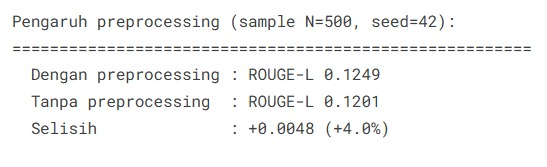

# UJI SKENARIO 4: Perbandingan Tiga Model Abstractive

In [4]:
# ============================================================
# UJI SKENARIO 4 — Perbandingan Tiga Model Abstractive
# ============================================================
# Bandingkan IndoBART, T5, PEGASUS pada seluruh dataset dengan ROUGE.
# Ringkasan ketiga model sudah dihasilkan, tinggal evaluasi.

rows = []
for name, col in models:
    r1, r2, rl = [], [], []
    for pred, ref in zip(df[col], df['lead_paragraph']):
        s = scorer.score(str(ref), str(pred))
        r1.append(s['rouge1'].fmeasure)
        r2.append(s['rouge2'].fmeasure)
        rl.append(s['rougeL'].fmeasure)
    rows.append({'model': name, 'rouge1': np.mean(r1),
                 'rouge2': np.mean(r2), 'rougeL': np.mean(rl)})

hasil_model = pd.DataFrame(rows)
print('Perbandingan tiga model abstractive:')
print('=' * 55)
print(hasil_model.round(4).to_string(index=False))

best = hasil_model.loc[hasil_model['rougeL'].idxmax(), 'model']
print(f'\nModel abstractive terbaik (ROUGE-L): {best}')

Perbandingan tiga model abstractive:
   model  rouge1  rouge2  rougeL
IndoBART  0.1649  0.0375  0.1128
      T5  0.1729  0.0416  0.1172
 PEGASUS  0.1573  0.0365  0.1108

Model abstractive terbaik (ROUGE-L): T5


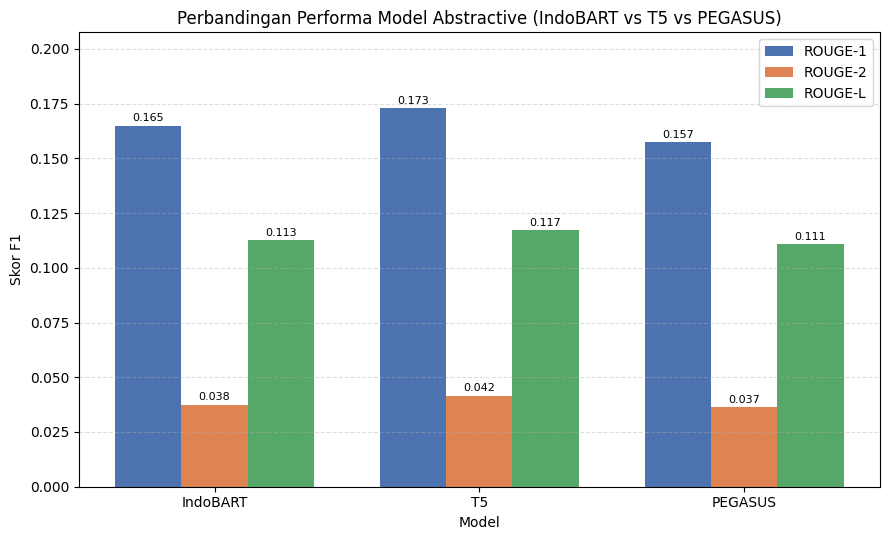

In [5]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(hasil_model))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5.5))

bars1 = ax.bar(x - width, hasil_model['rouge1'], width, label='ROUGE-1', color='#4C72B0')
bars2 = ax.bar(x,         hasil_model['rouge2'], width, label='ROUGE-2', color='#DD8452')
bars3 = ax.bar(x + width, hasil_model['rougeL'], width, label='ROUGE-L', color='#55A868')

ax.set_xlabel('Model')
ax.set_ylabel('Skor F1')
ax.set_title('Perbandingan Performa Model Abstractive (IndoBART vs T5 vs PEGASUS)')
ax.set_xticks(x)
ax.set_xticklabels(hasil_model['model'])
ax.legend()
ax.set_ylim(0, max(hasil_model[['rouge1','rouge2','rougeL']].max()) * 1.2)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# label angka di atas tiap bar
for bars in [bars1, bars2, bars3]:
    for b in bars:
        h = b.get_height()
        ax.annotate(f'{h:.3f}', xy=(b.get_x() + b.get_width()/2, h),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('perbandingan_model.png', dpi=200)
plt.show()

### Skenario 4 (lanjutan) — Evaluasi BERTScore

ROUGE mengukur kesamaan leksikal (n-gram yang sama persis), sehingga
kurang adil untuk model abstractive yang sering melakukan parafrase.
**BERTScore** mengukur kemiripan SEMANTIK menggunakan contextual
embedding, sehingga ringkasan yang bermakna sama meski berbeda kata
tetap mendapat skor tinggi. Dihitung pada sample acak karena BERTScore
cukup berat secara komputasi (load model + encoding).

In [38]:
# ============================================================
# BERTScore — hitung pada sampel untuk ketiga model abstractive
# ============================================================
# BERTScore agak berat (load model + encoding), jadi dihitung pada sampel acak.
# Pakai sampel yang sama (seed=42) agar ketiga model dibandingkan adil.

SAMPLE_SIZE_BS = 500
sample_bs = df.sample(n=min(SAMPLE_SIZE_BS, len(df)), random_state=42).reset_index(drop=True)
refs = sample_bs['lead_paragraph'].astype(str).tolist()

def hitung_bertscore(pred_col):
    cands = sample_bs[pred_col].astype(str).tolist()
    P, R, F1 = bertscore(cands, refs, lang='id', verbose=False)
    return P.mean().item(), R.mean().item(), F1.mean().item()

print(f'Menghitung BERTScore pada {len(sample_bs)} artikel sampel...\n')

print(f'{"Model":<10} | {"Precision":>9} | {"Recall":>9} | {"F1":>9}')
print('-' * 48)
hasil_bertscore = {}
for name, col in models:
    p, r, f1 = hitung_bertscore(col)
    hasil_bertscore[name] = (p, r, f1)
    print(f'{name:<10} | {p:>9.4f} | {r:>9.4f} | {f1:>9.4f}')

# Perbandingan: peringkat ROUGE vs peringkat BERTScore
# Apakah model terbaik menurut ROUGE sama dengan menurut BERTScore?
hasil_rouge = {row['model']: (row['rouge1'], row['rouge2'], row['rougeL'])
               for _, row in hasil_model.iterrows()}

print('\nPerbandingan F1 (BERTScore) vs ROUGE-L (dihitung pada Skenario 4 di atas):')
print('=' * 55)
print(f'{"Model":<10} | {"BERTScore-F1":>12} | {"ROUGE-L":>9}')
print('-' * 40)
for name, col in models:
    bs_f1 = hasil_bertscore[name][2]
    rouge_l = hasil_rouge[name][2]
    print(f'{name:<10} | {bs_f1:>12.4f} | {rouge_l:>9.4f}')

best_bs = max(hasil_bertscore, key=lambda k: hasil_bertscore[k][2])
best_rouge = max(hasil_rouge, key=lambda k: hasil_rouge[k][2])
print(f'\nTerbaik menurut BERTScore : {best_bs}')
print(f'Terbaik menurut ROUGE-L   : {best_rouge}')

if best_bs != best_rouge:
    print('\n[!] Peringkat BERBEDA antara dua metrik — temuan menarik untuk laporan:')
    print('    metrik berbasis makna vs berbasis kata bisa memberi kesimpulan berbeda.')
else:
    print('\nKedua metrik sepakat pada model terbaik — hasil konsisten.')

Menghitung BERTScore pada 500 artikel sampel...

Model      | Precision |    Recall |        F1
------------------------------------------------


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


T5         |    0.6826 |    0.6408 |    0.6605


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


PEGASUS    |    0.6589 |    0.6144 |    0.6355

Perbandingan F1 (BERTScore) vs ROUGE-L (dihitung pada Skenario 4 di atas):
Model      | BERTScore-F1 |   ROUGE-L
----------------------------------------
IndoBART   |       0.6439 |    0.1128
T5         |       0.6605 |    0.1172
PEGASUS    |       0.6355 |    0.1108

Terbaik menurut BERTScore : T5
Terbaik menurut ROUGE-L   : T5

Kedua metrik sepakat pada model terbaik — hasil konsisten.


# UJI SKENARIO 5: Perbandingan Abstractive Terbaik vs Extractive Terbaik

Uji Skenario 5 sudah dilakukan di file uji-skenario-extractive.ipynb

# Uji Skenario Selesai